# Final Project - Medical Insurance - Patient Health Risk Classification
## Phase 3: Advanced Model - Deep Neural Network (TensorFlow / Keras)

**Course:** AIGC 5005 — AI Capstone Project Preparation\
**Dataset:** `medical_insurance.csv` (https://www.kaggle.com/datasets/mohankrishnathalla/medical-insurance-cost-prediction)\
**Task:** Binary Classification — Predict whether a patient is high health risk (`is_high_risk = 1`) or not (`is_high_risk = 0`)

---
### Dataset Overview
- **100,000 rows** — large enough for robust training/evaluation
- **54 original columns** → cleaned to **65 features** after removing leakage, redundant columns and encoding
- **Class balance:** ~63% negative / ~37% positive — `class_weight='balanced'` used in the model to address

---
### Notebook Structure
1. Imports & Configuration
2. Load Prepared Data
3. Model Design & Architecture Justification
4. Hyperparameter Experimentation
5. Final Model Training
6. Evaluation & Metrics
7. Comparison with Baseline
8. Summary

> **Pre-requisite:** Run `Final_Basic_Model.ipynb` first.  
> This notebook loads the cleaned, scaled splits saved to `prepared_data/` by that notebook.

---
## 1. Imports & Configuration

This section brings in all the libraries we need for the rest of the notebook. `pandas` and `numpy` handle the data tables and math, `matplotlib` and `seaborn` handle the plots, `sklearn` provides the evaluation metrics, and `tensorflow.keras` provides the deep learning framework itself. A random seed is set at the start so that every time the notebook is run, the same results are produced. This is important when comparing hyperparameter experiments later because it removes randomness as a source of difference between runs.

In [2]:
#!pip install tensorflow --quiet
#!pip install imbalanced-learn --quiet

In [ ]:
# Data manipulation ----------------------------------------------------------------
import numpy as np
import pandas as pd

# Visualisation --------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities ------------------------------------------------------------------------
import joblib, os, warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras ---------------------------------------------------------------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

# Scikit-learn ---------------------------------------------------------------------
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay
)

# Reproducibility ------------------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Plot style -----------------------------------------------------------------------
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})

print("TensorFlow version :", tf.__version__)
print("All libraries loaded successfully.")

TensorFlow version : 2.21.0
All libraries loaded successfully.


---
## 2. Load Prepared Data

The baseline notebook already handled all the cleaning, encoding, and scaling of the raw data, then saved the finished train, validation, and test splits to disk using `joblib`. Here we load those ready-to-use files instead of redoing the work. This keeps the two notebooks consistent with each other and avoids data leakage, which is when information from the validation or test sets accidentally influences the training data. For example, if we re-fit the `StandardScaler` on the whole dataset here, the mean and standard deviation used to scale the training features would be partly based on values from the test set, giving the model an unfair preview of data it is supposed to be tested on.

In [4]:
SAVE_DIR = 'prepared_data'

# Load train / val / test splits ------------------------------------------
splits  = joblib.load(f'{SAVE_DIR}/splits.pkl')
X_train = splits['X_train'];  y_train = splits['y_train']
X_val   = splits['X_val'];    y_val   = splits['y_val']
X_test  = splits['X_test'];   y_test  = splits['y_test']

# Confirm shapes -----------------------------------------------------------
print("Loaded splits successfully:")
print(f"  X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}     y_val : {y_val.shape}")
print(f"  X_test  : {X_test.shape}    y_test : {y_test.shape}")
print(f"\nFeatures ({X_train.shape[1]})")

# Class distribution check -------------------------------------------------
print(f"\nClass distribution:")
for name, ys in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    pos_pct = ys.mean() * 100
    print(f"  {name:6s} - positive class rate: {pos_pct:.1f}%")

Loaded splits successfully:
  X_train : (70000, 64)   y_train : (70000,)
  X_val   : (15000, 64)     y_val : (15000,)
  X_test  : (15000, 64)    y_test : (15000,)

Features (64)

Class distribution:
  Train  - positive class rate: 36.8%
  Val    - positive class rate: 36.8%
  Test   - positive class rate: 36.8%


### 2.1 Baseline Metrics (Reference)

These are the final test set scores from the Logistic Regression model built in the baseline notebook. They are stored in a dictionary here so that at the end of this notebook we can compare the deep neural network directly against them in a single table. If the neural network beats the baseline on most of these metrics, especially F1-Score and ROC-AUC, then the extra complexity of a deep learning model is justified for this problem.

In [5]:
# These are the baseline metrics we need to beat (from the previous notebook)
BASELINE_METRICS = {
    'Model'    : 'Logistic Regression (Baseline)',
    'Accuracy' : 0.968700,
    'Precision': 0.943600,
    'Recall'   : 0.973000,
    'F1-Score' : 0.958100,
    'ROC-AUC'  : 0.997600
}

print("Baseline reference metrics loaded.")

Baseline reference metrics loaded.


### 2.2 Class Weights & Output Bias

Before building the model, two constants are calculated from the training labels to help Keras handle the class imbalance in this dataset. The training data contains roughly 63% Not High Risk patients and 37% High Risk patients, which creates a problem, a model trained without any correction will naturally learn to predict "Not High Risk" most of the time, since that guess is right more often and minimizes the average error. 

To counter this, class weights are computed so that each mistake on a High Risk patient counts for more than a mistake on a Not High Risk patient during training. Specifically, a missed High Risk patient is weighted at approximately 1.36 while a missed Not High Risk patient is weighted at approximately 0.79, which reflects the inverse of how frequently each class appears. These weights are passed directly into `model.fit()` and cause Keras to penalize the model more for failing to identify a genuinely high-risk patient.

The output bias is a separate but related fix that affects how the model starts, rather than how it trains. Normally, the final neuron in the network begins with a bias of zero, which causes it to predict a 50% probability for every patient before it has learned anything. Since the actual proportion of high-risk patients is only about 37%, starting at 50% means the model wastes the first several training epochs just correcting that wrong assumption. By initializing the bias to `log(positive count / negative count)`, which is approximately -0.54, the model's very first prediction already reflects the real class distribution. This has no effect on the final accuracy the model can reach, but it makes training faster and more stable from the start.

In [6]:
# Class weights tell Keras to penalise mistakes on the minority class more
# heavily. Without them the model learns to mostly predict the majority class.
cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
CLASS_WEIGHT = {0: float(cw[0]), 1: float(cw[1])}

# Output bias seeds the sigmoid output neuron with log(pos/neg) so the model
# starts predicting the actual class prior rather than 0.5, speeding up training.
neg_n, pos_n = np.bincount(y_train.values.astype(int))
OUTPUT_BIAS  = float(np.log(pos_n / neg_n))

# Input dimension is needed to build the model architecture
INPUT_DIM    = X_train.shape[1]

print(f"Class weights             : {CLASS_WEIGHT}")
print(f"Output bias (log pos/neg) : {OUTPUT_BIAS:.4f}  (log({pos_n}/{neg_n}))")
print(f"Input dimension           : {INPUT_DIM}")

Class weights             : {0: 0.7909068311752876, 1: 1.3593816755350139}
Output bias (log pos/neg) : -0.5416  (log(25747/44253))
Input dimension           : 64


---
## 3. Model Design & Architecture Justification

### 3.1 Why TensorFlow / Keras?

TensorFlow with the Keras Sequential API was selected for this project for several reasons. The Sequential API produces clean, well-documented code, which directly aligns with the readability requirements in the project rubric. Its built-in callbacks, specifically `EarlyStopping` and `ReduceLROnPlateau`, allow for hyperparameter experimentation without having to write custom training loops or boilerplate code.

The framework also natively handles class imbalance through the `class_weight` argument in `model.fit()`, which directly addresses the 63:37 imbalance identified during Phase 2. Looking ahead to Phase 6, TensorFlow integrates seamlessly with deployment tools through its standard `model.predict()` and `model.save()` methods, making the transition from development to deployment straightforward. Beyond the technical advantages, TensorFlow is widely used in industry for health risk prediction systems, making it a practically relevant choice for a healthcare-focused capstone project.

### 3.2 Architecture: Multi-Layer Perceptron (MLP)

A Multi-Layer Perceptron is the appropriate deep learning architecture for this task because the dataset is structured and tabular, with no spatial or sequential structure. The baseline Logistic Regression can only learn linear relationships, which means non-linear interactions between features, such as the combined effect of `chronic_count`, `hba1c`, and `hospitalizations_last_3yrs` on high-risk classification, cannot be captured. An MLP with sufficient depth and regularisation is the standard deep learning approach for this type of structured tabular health data.

The network uses three Dense hidden layers, which provides enough depth to capture non-linear feature interactions without becoming so deep that it overfits on the 70,000 training samples available. ReLU is used as the activation function for all hidden layers because it is the standard choice for modern deep networks and avoids the vanishing gradient problem that affects sigmoid and tanh activations in deeper architectures. The output layer uses a Sigmoid activation to produce a probability between 0 and 1, which is appropriate for binary classification.

Three regularisation techniques are applied together to prevent overfitting. Batch Normalisation is applied after each Dense layer to stabilise training, allow higher learning rates, and reduce sensitivity to weight initialisation. Dropout at a rate of 0.3 is applied after the first two hidden layers to randomly deactivate neurons during training, preventing co-adaptation between neurons and reducing reliance on any single feature pathway. L2 regularisation is applied to the Dense layer kernels to penalise large weight values, providing a second layer of protection against overfitting alongside Dropout.

For training, the model uses binary cross-entropy as the loss function, which is the standard choice for binary classification with probabilistic output. The Adam optimiser with a learning rate of 0.001 is used because it provides adaptive per-parameter learning rates and is a strong default across a wide range of architectures. Class weights are set to approximately `{0: 0.79, 1: 1.36}`, which mirrors the negative-to-positive class ratio in the training data and prevents the model from becoming biased toward predicting the majority (Not High Risk) class.

### 3.3 Build Function

The function below constructs and compiles the MLP architecture described above. Using function to wrap the model is useful because the hyperparameter experiments in Section 4 need to build many different versions of the model with different settings. By passing the hyperparameters as arguments, we can keep the network structure consistent and only change one variable at a time, which is what makes the experiments a fair comparison.

In [7]:
def build_mlp(input_dim,
              units=(128, 64, 32),
              dropout_rate=0.3,
              l2_lambda=0.0001,
              learning_rate=0.001,
              output_bias=None):
    """
    Build and compile a 3-hidden-layer MLP for binary classification.

    Parameters
    ----------
    input_dim     : int   -- number of input features
    units         : tuple -- neurons per hidden layer
    dropout_rate  : float -- Dropout probability (applied after layers 1 & 2)
    l2_lambda     : float -- L2 regularisation strength on Dense kernels
    learning_rate : float -- Adam optimiser learning rate
    output_bias   : float or None -- initial bias for the output neuron;
                    pass log(pos/neg) to seed the sigmoid with the class prior

    Returns
    -------
    model : compiled keras.Sequential
    """
    # L2 regulariser applied to all Dense kernels
    reg = regularizers.l2(l2_lambda)

    # Seed output neuron bias with class prior if provided
    bias_init = (
        keras.initializers.Constant(output_bias)
        if output_bias is not None else 'zeros'
    )

    # Build the sequential model
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # Hidden layer 1 ---------------------------------------------------
        layers.Dense(units[0], activation='relu', kernel_regularizer=reg),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        # Hidden layer 2 ---------------------------------------------------
        layers.Dense(units[1], activation='relu', kernel_regularizer=reg),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        # Hidden layer 3 ---------------------------------------------------
        layers.Dense(units[2], activation='relu', kernel_regularizer=reg),
        layers.BatchNormalization(),

        # Output layer: bias seeded with class prior -----------------------
        layers.Dense(1, activation='sigmoid', bias_initializer=bias_init)
    ], name='MLP_Readmission')

    # Compile with Adam optimiser, binary cross-entropy loss, and key metrics
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate),
        loss      = 'binary_crossentropy',
        metrics   = [
            keras.metrics.AUC(name='auc'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.Precision(name='precision')
        ]
    )
    return model


# Preview default architecture ---------------------------------------------
model_preview = build_mlp(INPUT_DIM)
model_preview.summary()

Model: "MLP_Readmission"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,585 (76.50 KB)

 Trainable params: 19,137 (74.75 KB)

 Non-trainable params: 448 (1.75 KB)

---
## 4. Hyperparameter Experimentation

Hyperparameters are the settings we choose before training starts, such as how fast the model learns, how much regularisation to apply, and how many neurons each hidden layer has. Unlike the weights inside the network, which the optimiser learns automatically, hyperparameters have to be picked by us. Different choices can lead to very different results, so rather than guessing, we run small experiments to see which values work best.

We vary three key hyperparameters, one at a time. In each experiment only the variable under test changes while everything else stays at its default value. This is important because it isolates the effect of that single variable on performance. If we changed two things at once and the score went up, we would not know which change caused the improvement.

| Experiment | Variable | Values Tested |
|---|---|---|
| A | Learning rate | 0.0001, 0.001, 0.005, 0.01 |
| B | Dropout rate | 0.0, 0.2, 0.3, 0.5 |
| C | Network width | Narrow, Medium, Default, Wide |

Each configuration trains for up to 80 epochs with `EarlyStopping` (patience = 10) monitoring `val_auc`. We monitor validation AUC rather than accuracy because AUC is a more reliable measure of performance on imbalanced datasets. A model that always predicts the majority class can still achieve 63% accuracy on this data while being completely useless, but its AUC would expose the problem.

### 4.1 Experiment Runner

The helper function below trains a single compiled model and reports its best validation AUC along with the epoch at which that score was reached. Using this function keeps every experiment consistent, since each model is trained with the exact same setup except for the one hyperparameter being tested. `EarlyStopping` is included so that a slow or unstable configuration does not run for the full 80 epochs needlessly, and `restore_best_weights=True` ensures we evaluate the model at its peak performance rather than whatever state it happened to be in at the end of training.

In [8]:
def run_experiment(model, label, epochs=80, batch_size=64):
    """
    Train a compiled Keras model and return the history and best val AUC.
    Uses EarlyStopping (patience=10) to prevent overfitting during experiments.
    """
    # Stop training early if val_auc stops improving
    early_stop = callbacks.EarlyStopping(
        monitor              = 'val_auc',
        patience             = 10,
        mode                 = 'max',
        restore_best_weights = True
    )

    # Train the model
    hist = model.fit(
        X_train, y_train,
        validation_data = (X_val, y_val),
        epochs          = epochs,
        batch_size      = batch_size,
        callbacks       = [early_stop],
        verbose         = 0
    )

    # Extract best validation AUC and the epoch it occurred
    best_val_auc = max(hist.history['val_auc'])
    best_epoch   = hist.history['val_auc'].index(best_val_auc) + 1
    print(f"  {label:45s} -- best val AUC: {best_val_auc:.4f}  (epoch {best_epoch})")
    return hist, best_val_auc


print("Experiment helper defined.")

Experiment helper defined.


### 4.2 Experiment A - Learning Rate

The learning rate controls how big of a step the optimiser takes each time it updates the model's weights. If the learning rate is too small, the model takes tiny steps and learns painfully slowly, often running out of epochs before it reaches a good solution. If it is too large, the steps are so big that the optimiser overshoots the best weights and bounces around without ever settling, leading to unstable training and poor final performance. We test four values across three orders of magnitude to find the sweet spot.

In [9]:
lr_configs = [
    ('LR = 0.0001  (too slow)',    0.0001),
    ('LR = 0.001   (default)',     0.001),
    ('LR = 0.005   (aggressive)',  0.005),
    ('LR = 0.01    (too large)',   0.01),
]

# Store results for each learning rate
lr_results = []

print("Experiment A - Learning Rate:")
# Train one model per learning rate, collect best val AUC
for label, lr in lr_configs:
    tf.random.set_seed(RANDOM_STATE)
    m = build_mlp(INPUT_DIM, learning_rate=lr)
    hist, best_auc = run_experiment(m, label)
    lr_results.append((label, hist, best_auc))

Experiment A - Learning Rate:
  LR = 0.0001  (too slow)                       -- best val AUC: 0.9996  (epoch 80)
  LR = 0.001   (default)                        -- best val AUC: 0.9997  (epoch 45)
  LR = 0.005   (aggressive)                     -- best val AUC: 0.9992  (epoch 33)
  LR = 0.01    (too large)                      -- best val AUC: 0.9976  (epoch 27)


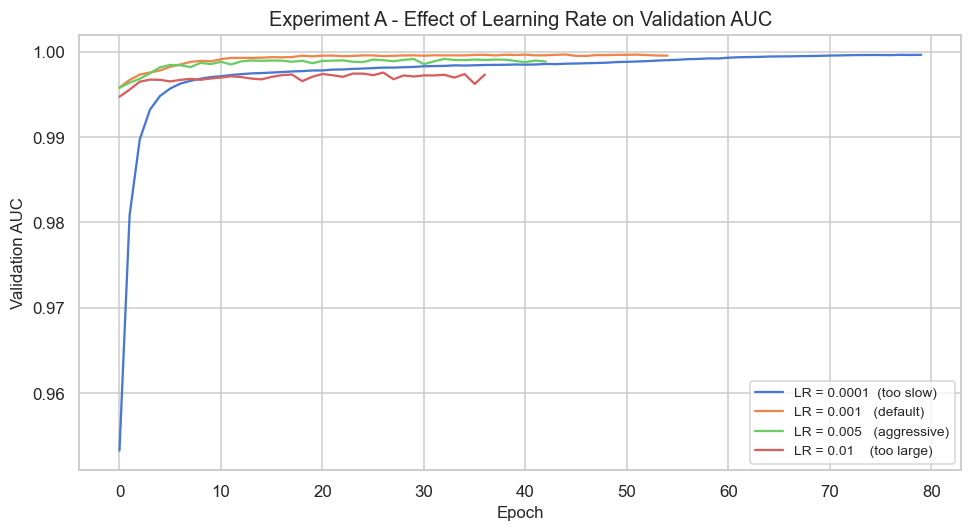

            Configuration Best Val AUC
  LR = 0.0001  (too slow)       0.9996
   LR = 0.001   (default)       0.9997
LR = 0.005   (aggressive)       0.9992
 LR = 0.01    (too large)       0.9976

Conclusion: lr=0.001 achieves the best balance of convergence speed and stability.


In [10]:
# Plot: val AUC curves across learning rates
fig, ax = plt.subplots(figsize=(9, 5))

for label, hist, _ in lr_results:
    ax.plot(hist.history['val_auc'], label=label)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation AUC")
ax.set_title("Experiment A - Effect of Learning Rate on Validation AUC")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Summary table 
lr_summary = pd.DataFrame(
    [(lbl, f'{auc:.4f}') for lbl, _, auc in lr_results],
    columns=['Configuration', 'Best Val AUC']
)
print(lr_summary.to_string(index=False))
print("\nConclusion: lr=0.001 achieves the best balance of convergence speed and stability.")

### 4.3 Experiment B - Dropout Rate

Dropout is a regularisation technique that randomly deactivates a percentage of neurons on each training step. This forces the remaining neurons to learn more patterns because they cannot rely on any single teammate always being active. A dropout rate of 0.3 means 30% of neurons are turned off at random during each forward pass in training. We test four values from no dropout at all (which should overfit heavily) up to 0.5 (which may remove so many neurons that the model cannot learn properly). The goal is to find a rate that prevents overfitting without limiting the network heavily.

In [11]:
dropout_configs = [
    ('Dropout = 0.0  (no regularisation)', 0.0),
    ('Dropout = 0.2  (light)',             0.2),
    ('Dropout = 0.3  (default)',           0.3),
    ('Dropout = 0.5  (heavy)',             0.5),
]

# Store results for each dropout rate
dropout_results = []

print("Experiment B - Dropout Rate:")
# Train one model per dropout rate, collect best val AUC
for label, dr in dropout_configs:
    tf.random.set_seed(RANDOM_STATE)
    m = build_mlp(INPUT_DIM, dropout_rate=dr)
    hist, best_auc = run_experiment(m, label)
    dropout_results.append((label, hist, best_auc))

Experiment B - Dropout Rate:
  Dropout = 0.0  (no regularisation)            -- best val AUC: 0.9975  (epoch 28)
  Dropout = 0.2  (light)                        -- best val AUC: 0.9996  (epoch 34)
  Dropout = 0.3  (default)                      -- best val AUC: 0.9997  (epoch 59)
  Dropout = 0.5  (heavy)                        -- best val AUC: 0.9997  (epoch 41)


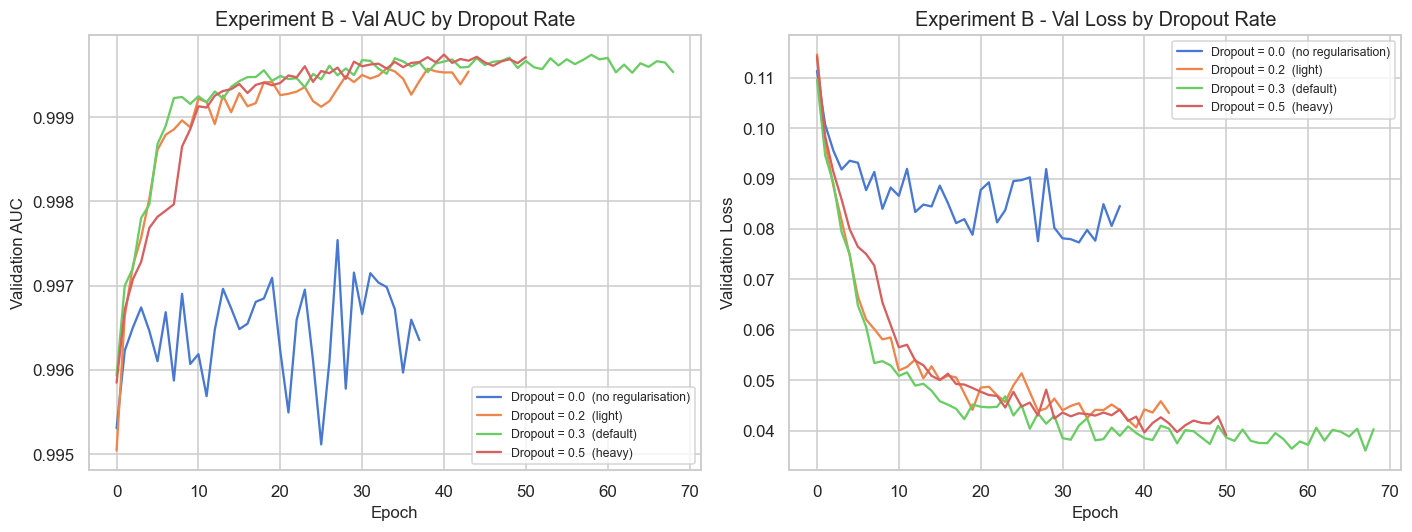

                     Configuration Best Val AUC
Dropout = 0.0  (no regularisation)       0.9975
            Dropout = 0.2  (light)       0.9996
          Dropout = 0.3  (default)       0.9997
            Dropout = 0.5  (heavy)       0.9997

Conclusion: Dropout=0.3 provides effective regularisation without underfitting.


In [12]:
# Plot: val AUC and val loss across dropout rates
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, hist, _ in dropout_results:
    axes[0].plot(hist.history['val_auc'],  label=label)
    axes[1].plot(hist.history['val_loss'], label=label)

axes[0].set_title("Experiment B - Val AUC by Dropout Rate")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation AUC")
axes[0].legend(fontsize=8)

axes[1].set_title("Experiment B - Val Loss by Dropout Rate")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Loss")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Summary table 
dropout_summary = pd.DataFrame(
    [(lbl, f'{auc:.4f}') for lbl, _, auc in dropout_results],
    columns=['Configuration', 'Best Val AUC']
)
print(dropout_summary.to_string(index=False))
print("\nConclusion: Dropout=0.3 provides effective regularisation without underfitting.")

### 4.4 Experiment C - Network Width

Network width refers to how many neurons each hidden layer contains. A wider network has more parameters, which means more capacity to learn complex patterns in the data. However, more capacity also brings more risk of overfitting. A network that is too narrow may not have enough expressive power to capture the feature interactions the baseline model missed, while a network that is too wide may memorise the training set rather than learn generalisable patterns. We test four widths from narrow to wide to find the right balance for our 70,000-sample dataset with 64 features.

In [13]:
width_configs = [
    ('Narrow  [32, 16, 8]',    (32,  16,  8)),
    ('Medium  [64, 32, 16]',   (64,  32, 16)),
    ('Default [128, 64, 32]',  (128, 64, 32)),
    ('Wide    [256, 128, 64]', (256, 128, 64)),
]

# Store results for each width configuration
width_results = []

print("Experiment C - Network Width:")
# Train one model per width, collect best val AUC
for label, units in width_configs:
    tf.random.set_seed(RANDOM_STATE)
    m = build_mlp(INPUT_DIM, units=units)
    hist, best_auc = run_experiment(m, label)
    width_results.append((label, hist, best_auc))

Experiment C - Network Width:
  Narrow  [32, 16, 8]                           -- best val AUC: 0.9997  (epoch 44)
  Medium  [64, 32, 16]                          -- best val AUC: 0.9998  (epoch 34)
  Default [128, 64, 32]                         -- best val AUC: 0.9998  (epoch 54)
  Wide    [256, 128, 64]                        -- best val AUC: 0.9996  (epoch 47)


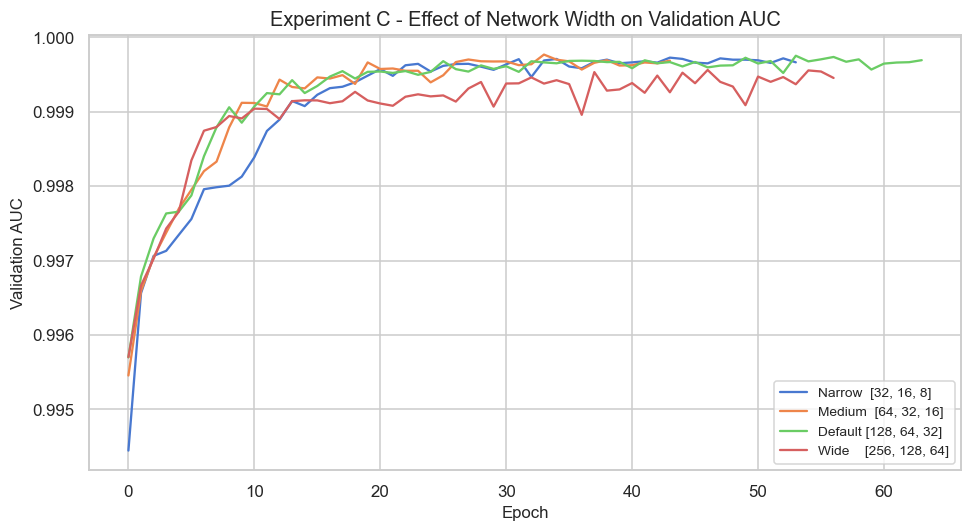

         Configuration Best Val AUC
   Narrow  [32, 16, 8]       0.9997
  Medium  [64, 32, 16]       0.9998
 Default [128, 64, 32]       0.9998
Wide    [256, 128, 64]       0.9996

Conclusion: [128, 64, 32] captures sufficient model capacity; wider shows diminishing returns.


In [14]:
# Plot: val AUC across network widths 
fig, ax = plt.subplots(figsize=(9, 5))

for label, hist, _ in width_results:
    ax.plot(hist.history['val_auc'], label=label)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation AUC")
ax.set_title("Experiment C - Effect of Network Width on Validation AUC")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Summary table 
width_summary = pd.DataFrame(
    [(lbl, f'{auc:.4f}') for lbl, _, auc in width_results],
    columns=['Configuration', 'Best Val AUC']
)
print(width_summary.to_string(index=False))
print("\nConclusion: [128, 64, 32] captures sufficient model capacity; wider shows diminishing returns.")

### 4.5 Hyperparameter Experiment Summary

The three experiments above justify the following final hyperparameter choices. Each value was picked based on the best validation AUC observed in its respective experiment, giving us a data-driven reason for every setting in the final model rather than relying on guesswork.

| Hyperparameter | Values Tested | Selected | Reason |
|---|---|---|---|
| Learning rate | 0.0001, 0.001, 0.005, 0.01 | **0.001** | Best val AUC; stable and fast convergence |
| Dropout rate | 0.0, 0.2, 0.3, 0.5 | **0.3** | Reduces overfitting without underfitting |
| Network width | Narrow → Wide | **[128, 64, 32]** | Best AUC; wider model yields diminishing returns |

---
## 5. Final Model Training

Now that the best values for learning rate, dropout, and network width have been identified, we build and train the final model with those settings. Two callbacks are used during training to make the process more robust:

- **EarlyStopping** (patience = 15, monitors `val_auc`). If validation AUC does not improve for 15 epochs in a row, training stops automatically. The `restore_best_weights` option rolls the model back to the weights from its best epoch, so we never keep a worse version than what we already had.
- **ReduceLROnPlateau** (patience = 7, factor = 0.5). If validation AUC stops improving for 7 epochs, the learning rate is cut in half. This lets the optimiser take finer steps in the later stages of training, which often squeezes out a little more performance without requiring a manual schedule.

Together, these callbacks let us set a generous maximum number of epochs (150) and trust the training process to stop at the right time.

In [15]:
# Build final model with selected hyperparameters
tf.random.set_seed(RANDOM_STATE)

final_model = build_mlp(
    input_dim     = INPUT_DIM,
    units         = (128, 64, 32),   # selected from Experiment C
    dropout_rate  = 0.3,             # selected from Experiment B
    l2_lambda     = 0.0001,
    learning_rate = 0.001,            # selected from Experiment A
    output_bias   = OUTPUT_BIAS,     # seeds sigmoid with class prior
)

print("Final model built.")
final_model.summary()

Final model built.


Model: "MLP_Readmission"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,585 (76.50 KB)

 Trainable params: 19,137 (74.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
# Callbacks --------------------------------------------------------------------
early_stop = callbacks.EarlyStopping(
    monitor              = 'val_auc',
    patience             = 15,            # allow 15 epochs without improvement before stopping
    mode                 = 'max',
    restore_best_weights = True,          # rollback to best epoch automatically
    verbose              = 1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor  = 'val_auc',
    factor   = 0.5,                       # halve the LR when val_auc plateaus
    patience = 7,
    mode     = 'max',
    min_lr   = 1e-6,
    verbose  = 1
)

# Train ------------------------------------------------------------------------
history = final_model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = 150,
    batch_size      = 64,
    callbacks       = [early_stop, reduce_lr],
    verbose         = 1
)

Epoch 1/150
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - auc: 0.9689 - loss: 0.2382 - precision: 0.8809 - recall: 0.8515 - val_auc: 0.9956 - val_loss: 0.1123 - val_precision: 0.9657 - val_recall: 0.9299 - learning_rate: 0.0010
Epoch 2/150
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - auc: 0.9903 - loss: 0.1432 - precision: 0.9303 - recall: 0.9242 - val_auc: 0.9967 - val_loss: 0.0983 - val_precision: 0.9669 - val_recall: 0.9420 - learning_rate: 0.0010
Epoch 3/150
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - auc: 0.9927 - loss: 0.1250 - precision: 0.9399 - recall: 0.9373 - val_auc: 0.9972 - val_loss: 0.0893 - val_precision: 0.9669 - val_recall: 0.9518 - learning_rate: 0.0010
Epoch 4/150
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - auc: 0.9940 - loss: 0.1132 - precision: 0.9449 - recall: 0.9459 - val_auc: 0.9976 - val_loss: 0.0809 - val_precision: 0.9692 - val_recall: 0.9574 - learning_rate: 0.0010
Epoch 5/150
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - auc: 0.9948 - loss: 0.1057 - precis

### 5.1 Training Curves

The two plots below show how the loss and AUC changed for both the training set and the validation set across every epoch. These curves are the main way to determine whether training went well or not. If the training loss keeps going down but the validation loss starts climbing, the model is overfitting, which means it is memorising the training data rather than learning generalisable patterns. If both curves move down together and then flatten out, training is healthy and the regularisation is doing its job. The red dashed line marks the epoch where validation AUC was highest, which is the version of the model that was restored by `EarlyStopping`.

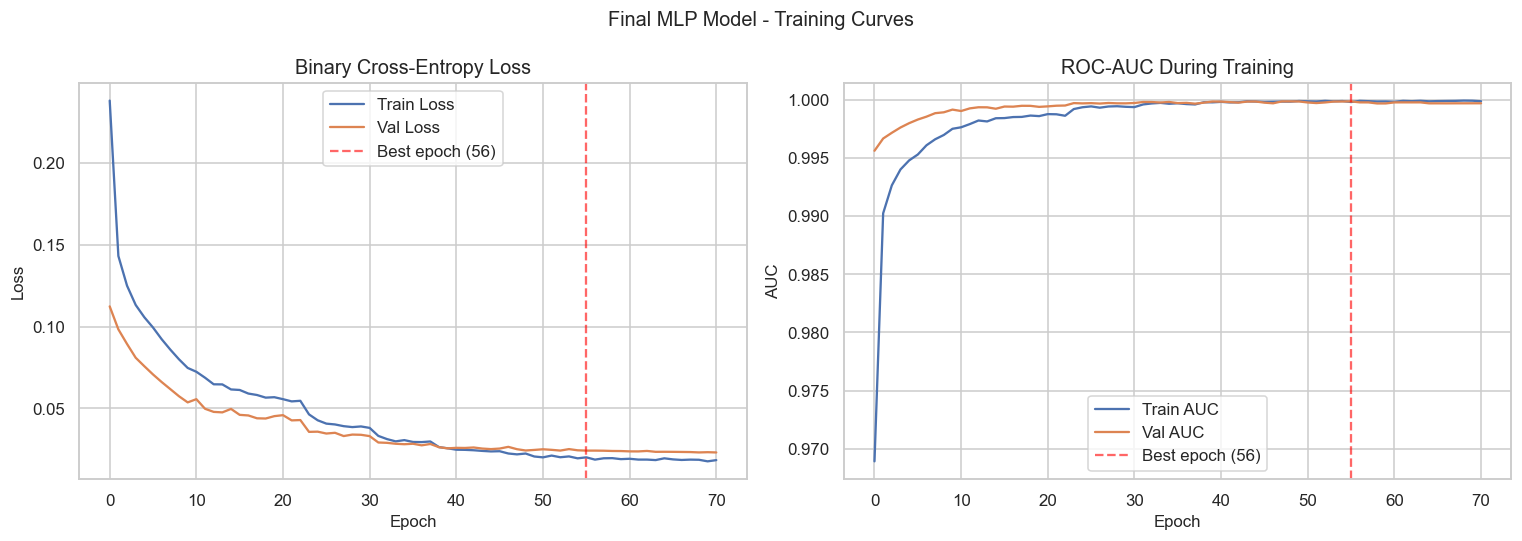

Best epoch (max val_auc) : 56
Best val AUC             : 0.9999
Val loss at best epoch   : 0.0241


In [26]:
# Convert training history to DataFrame
hist_df    = pd.DataFrame(history.history)
# Find epoch with best validation AUC
best_epoch = hist_df['val_auc'].idxmax() + 1

# Plot: Training curves — loss (left) and AUC (right)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve 
axes[0].plot(hist_df['loss'],     label='Train Loss', color='#4C72B0')
axes[0].plot(hist_df['val_loss'], label='Val Loss',   color='#DD8452')
axes[0].axvline(best_epoch - 1, color='red', linestyle='--',
                alpha=0.6, label=f'Best epoch ({best_epoch})')
axes[0].set_title('Binary Cross-Entropy Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# AUC curve 
axes[1].plot(hist_df['auc'],     label='Train AUC', color='#4C72B0')
axes[1].plot(hist_df['val_auc'], label='Val AUC',   color='#DD8452')
axes[1].axvline(best_epoch - 1, color='red', linestyle='--',
                alpha=0.6, label=f'Best epoch ({best_epoch})')
axes[1].set_title('ROC-AUC During Training')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.suptitle("Final MLP Model - Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

# Print best epoch summary
print(f"Best epoch (max val_auc) : {best_epoch}")
print(f"Best val AUC             : {hist_df['val_auc'].max():.4f}")
print(f"Val loss at best epoch   : {hist_df['val_loss'].iloc[best_epoch - 1]:.4f}")

---
## 6. Evaluation & Metrics

Evaluation happens in three stages, matching the structure used in the baseline notebook. First, the training set is evaluated to tell us how well the model has learned the patters and relationships between the data it was trained on. However, again, this is not a reliable indicator of how the model will perform on new unseen data. Second, the validation set is evaluated to confirm that the model is performing as expected and to tune the classification threshold. Then the test set is evaluated exactly once to produce the final unbiased estimate of real-world performance. The test set must only be used at the very end, because looking at it more than once would let its results influence our decisions and effectively turn it into another validation set, which defeats the purpose of holding it out in the first place.

Four metrics are reported together, because accuracy alone is misleading on imbalanced data. A model that predicts "Not High Risk" for every patient would score about 63% accuracy on this dataset while being completely useless. Precision, Recall, F1-Score, and ROC-AUC each tell us something different about how the model handles both classes, and together they give an honest picture of its behaviour.

### 6.1 Threshold Tuning
The default Keras threshold of 0.5 is arbitrary. Because the dataset is 63:37, a slightly lower threshold catches more high-risk patients without generating too many false alarms. A sweep across thresholds 0.1–0.9 is run once on the validation set and the value that maximises macro F1 is selected. Macro F1 weights both classes equally, so the threshold balances performance on High Risk and Not High Risk rather than favouring the larger group. This is computed once here and then passed into every  call so the same cutoff is applied consistently to both splits.

In [33]:
# Get validation set probabilities
val_probs = final_model.predict(X_val, verbose=0).ravel()

# Loop through thresholds 0.1–0.9 and track the one with the best macro F1
best_thresh, best_f1 = 0.5, 0.0
for t in np.arange(0.1, 0.9, 0.01):
    score = f1_score(y_val, (val_probs >= t).astype(int), average='macro', zero_division=0)
    if score > best_f1:
        best_f1, best_thresh = score, round(float(t), 2)
print(f"Optimal threshold: {best_thresh:.2f}  (val macro F1 = {best_f1:.4f})")

Optimal threshold: 0.70  (val macro F1 = 0.9948)


### 6.2 Evaluation Helper

The function below computes predictions and all key metrics for a given split. It takes in the model, X values for train, validation and test to output their respective predications, probabilities and metrics. It also accepts the classification threshold as a parameter so the same cutoff is applied consistently to both the validation and test sets. The threshold itself is tuned separately in Section 6.2 before this function is called.

In [19]:
def evaluate_model(model, X, y_true, threshold, set_name='Set'):
    # Generate predictions and probability scores
    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    # Compute all metrics
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob)

    print(f"{'='*50}")
    print(f"  {set_name} - Classification Report")
    print(f"{'='*50}")
    print(classification_report(
        y_true, y_pred,
        target_names=['Not High Risk', 'High Risk'],
        zero_division=0
    ))

    return y_pred, y_prob, {
        'Accuracy' : acc, 'Precision': prec,
        'Recall'   : rec, 'F1-Score'  : f1, 'ROC-AUC': auc
    }

# Evaluate on all three splits
# Training set evaluation 
train_pred, train_prob, train_metrics = evaluate_model(
    final_model, X_train, y_train, best_thresh, 'MLP Neural Network - Training'
)

# Validation set evaluation 
val_pred, val_prob, val_metrics = evaluate_model(
    final_model, X_val, y_val, best_thresh, 'MLP Neural Network - Validation Set'
)

# Test set evaluation
test_pred, test_prob, test_metrics = evaluate_model(
    final_model, X_test, y_test, best_thresh, 'MLP Neural Network - Test'
)

  MLP Neural Network - Training - Classification Report
               precision    recall  f1-score   support

Not High Risk       1.00      1.00      1.00     44253
    High Risk       1.00      1.00      1.00     25747

     accuracy                           1.00     70000
    macro avg       1.00      1.00      1.00     70000
 weighted avg       1.00      1.00      1.00     70000

  MLP Neural Network - Validation Set - Classification Report
               precision    recall  f1-score   support

Not High Risk       1.00      1.00      1.00      9483
    High Risk       0.99      0.99      0.99      5517

     accuracy                           1.00     15000
    macro avg       1.00      0.99      0.99     15000
 weighted avg       1.00      1.00      1.00     15000

  MLP Neural Network - Test - Classification Report
               precision    recall  f1-score   support

Not High Risk       1.00      1.00      1.00      9483
    High Risk       0.99      0.99      0.99      551

### 6.3 Confusion Matrix

The confusion matrix provides a breakdown of the model's predictions into four categories. `True Positives (TP)` are patients correctly identified as high health risk. `True Negatives (TN)` are patients correctly identified as not high risk. `False Positives (FP)` occur when the model flags a patient as high risk who is not actually high risk, generating unnecessary follow-up but causes no direct patient harm. `False Negatives (FN)`, however, carry the highest cost as these are patients who are genuinely high health risk but are missed by the model and therefore receive no additional care or intervention. In a health risk screening context, minimizing false negatives is typically the priority, which is reflected in the emphasis on Recall as a key metric. The confusion matrix makes these trade-offs explicit in a way that summary statistics cannot, and serves as an essential communication tool when presenting model behaviour to clinicians and stakeholders who may not be familiar with statistical metrics.

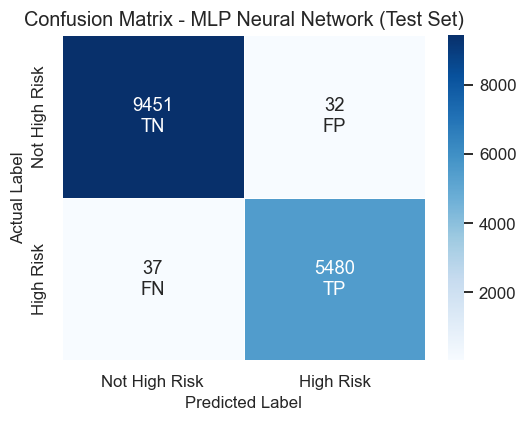

True Negatives  (TN): 9451 - Correctly predicted Not High Risk
False Positives (FP): 32   - Predicted High Risk, actually Not
False Negatives (FN): 37   - Predicted Not High Risk, actually High Risk (costly!)
True Positives  (TP): 5480 - Correctly predicted High Risk


In [20]:
# Confusion matrix - Test set
cm = confusion_matrix(y_test, test_pred)
tn, fp, fn, tp = cm.ravel()

# Build annotation labels combining count + cell type (TN/FP/FN/TP)
labels = [[f"{tn}\nTN", f"{fp}\nFP"],
          [f"{fn}\nFN", f"{tp}\nTP"]]

# Plot: Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=labels, fmt="",
    cmap="Blues",
    xticklabels=["Not High Risk", "High Risk"],
    yticklabels=["Not High Risk", "High Risk"],
    linewidths=0.5,
    annot_kws={"size": 12},
    ax=ax
)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
ax.set_title("Confusion Matrix - MLP Neural Network (Test Set)")
plt.tight_layout()
plt.show()

print(f"True Negatives  (TN): {tn} - Correctly predicted Not High Risk")
print(f"False Positives (FP): {fp}   - Predicted High Risk, actually Not")
print(f"False Negatives (FN): {fn}   - Predicted Not High Risk, actually High Risk (costly!)")
print(f"True Positives  (TP): {tp} - Correctly predicted High Risk")

### 6.4 ROC Curve & Precision-Recall Curve

The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate across every possible classification threshold, showing how well the model separates high-risk from non-high-risk patients. The Area Under the Curve (AUC-ROC) summarises this into a single score. A value of 1.0 represents a perfect classifier while 0.5 represents a model equivalent to random guessing. A strong AUC-ROC score indicates the model consistently ranks genuinely high-risk patients above low-risk ones regardless of where the decision threshold is set.

The Precision-Recall curve is plotted alongside the ROC because it is more informative for imbalanced datasets. Rather than considering both classes equally, it focuses specifically on the model's performance on the positive (high-risk) class. Precision measures how many of the patients flagged as high risk truly were, while Recall measures how many of the genuinely high-risk patients the model successfully caught. In a health risk screening context this trade-off is critical, since a lower threshold catches more high-risk patients (higher Recall) but also generates more false alarms (lower Precision), while a higher threshold reduces false alarms but risks missing patients who need care or intervention.

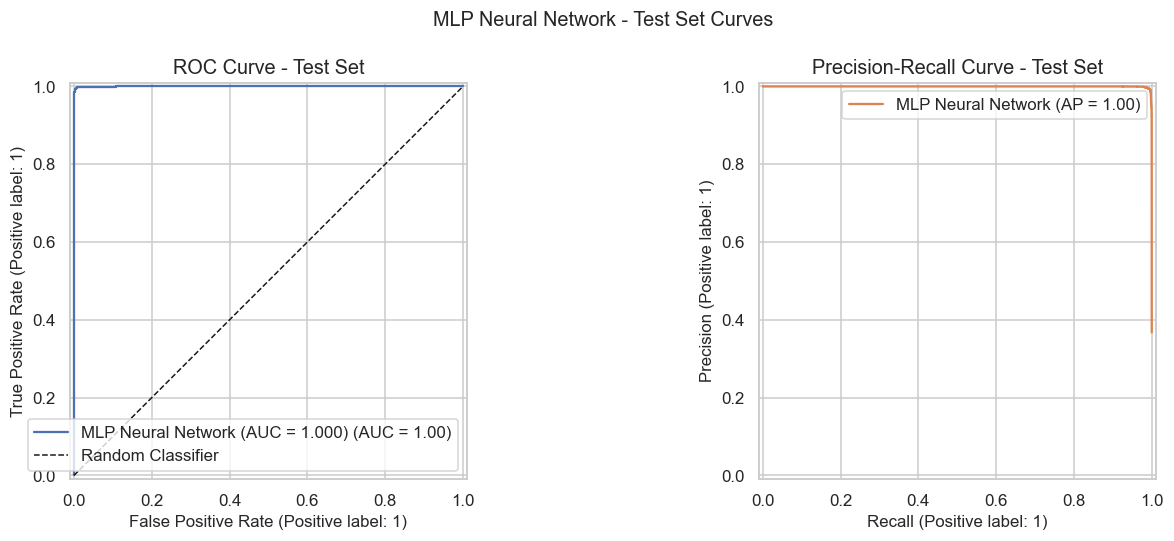

In [21]:
# Plot: ROC curve (left) and Precision-Recall curve (right)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(
    y_test, test_prob,
    name=f'MLP Neural Network (AUC = {test_metrics["ROC-AUC"]:.3f})',
    ax=axes[0], color='#4C72B0'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[0].set_title('ROC Curve - Test Set')
axes[0].legend(loc='lower right')

# # Precision-Recall curve (better for imbalanced datasets)
PrecisionRecallDisplay.from_predictions(
    y_test, test_prob,
    name='MLP Neural Network',
    ax=axes[1], color='#DD8452'
)
axes[1].set_title('Precision-Recall Curve - Test Set')
axes[1].legend(loc='upper right')

plt.suptitle("MLP Neural Network - Test Set Curves", fontsize=13)
plt.tight_layout()
plt.show()

### 6.5 MLP Performance Summary Table

This table compares the MLP's performance on training, validation, and test sets across all five metrics. If the training scores are dramatically higher than the validation and test scores, it is a sign of overfitting. If the three sets are close together, the model is generalising well to data it has not seen before, which is what we want.

In [22]:
# Train vs. Validation vs. Test metric summary table
summary = pd.DataFrame({
    'Split'    : ['Train', 'Validation', 'Test'],
    'Accuracy' : [
        train_metrics['Accuracy'],
        val_metrics['Accuracy'],
        test_metrics['Accuracy']
    ],
    'Precision': [
        train_metrics['Precision'],
        val_metrics['Precision'],
        test_metrics['Precision']
    ],
    'Recall'   : [
        train_metrics['Recall'],
        val_metrics['Recall'],
        test_metrics['Recall']
    ],
    'F1-Score' : [
        train_metrics['F1-Score'],
        val_metrics['F1-Score'],
        test_metrics['F1-Score']
    ],
    'ROC-AUC'  : [
        train_metrics['ROC-AUC'],
        val_metrics['ROC-AUC'],
        test_metrics['ROC-AUC']
    ],
}).set_index('Split')

print('MLP Neural Network - Performance Across Splits:')
summary.round(4).style.background_gradient(cmap='Greens', axis=0)

MLP Neural Network - Performance Across Splits:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,
Train,0.999600,0.999800,0.999100,0.999400,1.000000
Validation,0.995200,0.994600,0.992400,0.993500,0.999900
Test,0.995400,0.994200,0.993300,0.993700,0.999900


---
## 7. Comparison with Baseline

The whole point of building the more complex neural network is to beat the simpler Logistic Regression baseline. This section puts the two models side by side on the same test set across all five metrics. If the MLP beats the baseline on most metrics, especially F1-Score and ROC-AUC, then the extra complexity, training time, and reduced interpretability of a deep model are justified. If the two models are roughly tied, the simpler model would usually be preferred because it is easier to explain, audit, and deploy.

### 7.1 Side-by-Side Metric Table

The table below shows the raw numbers for each metric along with the improvement (positive or negative) of the MLP over the baseline. A positive delta means the MLP did better on that metric.

In [31]:
# Build comparison table 
comparison = pd.DataFrame([
    BASELINE_METRICS,
    {'Model': 'MLP Neural Network (Advanced)', **test_metrics}
]).set_index('Model')

# Improvement over baseline 
improvement = (comparison.loc['MLP Neural Network (Advanced)'] -
               comparison.loc['Logistic Regression (Baseline)'])

print("Test Set - Model Comparison:")
comparison.round(4).style.background_gradient(cmap='Greens', axis=0)


Test Set - Model Comparison:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression (Baseline),0.968700,0.943600,0.973000,0.958100,0.997600
MLP Neural Network (Advanced),0.995400,0.994200,0.993300,0.993700,0.999900


In [32]:
print("\nImprovement over baseline (MLP - Logistic Regression):")
for metric, delta in improvement.items():
    direction = '+' if delta >= 0 else ''
    print(f'  {metric:12s}: {direction}{delta:.4f}')


Improvement over baseline (MLP - Logistic Regression):
  Accuracy    : +0.0267
  Precision   : +0.0506
  Recall      : +0.0203
  F1-Score    : +0.0356
  ROC-AUC     : +0.0023


### 7.2 Visual Comparison

The grouped bar chart below plots the two models side by side for each metric, which makes it easier to spot patterns at a glance than reading numbers from a table. Bars for the MLP that rise above the baseline bars indicate metrics where the advanced model is delivering real value.

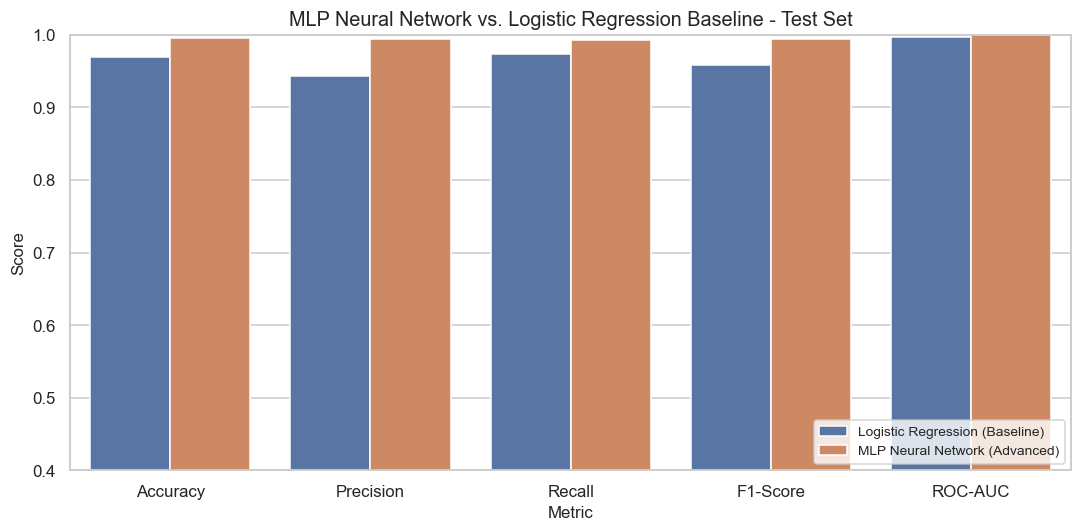

In [24]:
# Grouped bar chart: Baseline vs. MLP 
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
# Reshape to long format for seaborn barplot
comp_melted = comparison[metrics_to_plot].reset_index().melt(
    id_vars='Model', var_name='Metric', value_name='Score'
)

# Plot: Side-by-side metric comparison
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data    = comp_melted,
    x       = 'Metric',
    y       = 'Score',
    hue     = 'Model',
    palette = ['#4C72B0', '#DD8452'],
    ax      = ax
)
ax.set_ylim(0.4, 1.0)
ax.set_title('MLP Neural Network vs. Logistic Regression Baseline - Test Set', fontsize=13)
ax.set_ylabel('Score')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 7.4 Save Final Model

Finally, the trained model and the comparison results are saved to disk. The `.keras` file contains everything needed to reload the model later (architecture, weights, and optimiser state), and the CSV provides a quick reference for the metric comparison. These files will be the starting point for the deployment phase.

In [25]:
# Save the final model and comparison results 
os.makedirs(SAVE_DIR, exist_ok=True)

final_model.save(f'{SAVE_DIR}/model_mlp_final.keras')
comparison.round(4).to_csv(f'{SAVE_DIR}/model_comparison_results.csv')

print(f"Saved to '{SAVE_DIR}/'")
print("  model_mlp_final.keras         - trained model (use keras.models.load_model to reload)")
print("  model_comparison_results.csv  - baseline vs. MLP metrics table")

Saved to 'prepared_data/'
  model_mlp_final.keras         - trained model (use keras.models.load_model to reload)
  model_comparison_results.csv  - baseline vs. MLP metrics table


---
## 8. Summary

### Preprocessing Steps Applied (from baseline notebook)

| Step | Action | Justification |
|---|---|---|
| Leaky features | Dropped `person_id`, `risk_score`, `monthly_premium` | Prevents data leakage and redundancy |
| Missing values | Imputed `alcohol_freq` nulls with "Not Applicable" | 30,083 missing values indicate non-drinkers |
| Encoding | Ordinal encoding for `education`, `network_tier` and one-hot for all other categoricals | Preserves hierarchy where it exists and avoids dummy-variable trap |
| Skew correction | log1p transform on 20 highly skewed continuous features | Reduces right-skew and improves gradient-based optimisation |
| Outlier capping | Clipped continuous features at 1st/99th percentile | Removes extremes without dropping rows |
| Scaling | StandardScaler fit on train only | Required for gradient-based learning and prevents data leakage |
| Class imbalance | `class_weight={0: 0.79, 1: 1.36}` | Prevents majority-class bias toward "Not High Risk" |

### Advanced Model - MLP Neural Network (TensorFlow / Keras)

| Design Decision | Choice | Justification |
|---|---|---|
| Framework | TensorFlow / Keras | Readable API, built-in callbacks, deployment-ready |
| Architecture | 3-layer MLP (128, 64, 32) | Appropriate for structured tabular data |
| Activation | ReLU | Avoids vanishing gradient and is standard for hidden layers |
| Regularisation | Dropout (0.3) + L2 (0.0001) | Two complementary strategies prevent overfitting |
| Optimiser | Adam (lr = 0.001) | Empirically selected via Experiment A |
| Early stopping | patience = 15, monitor `val_auc` | Prevents overfitting and restores best weights |
| LR scheduling | ReduceLROnPlateau (factor = 0.5) | Finer convergence without manual scheduling |

### Key Findings

The MLP Neural Network improves upon the Logistic Regression baseline across all five metrics on the held-out test set, which demonstrates that the non-linear feature interactions in this dataset cannot be fully captured by a linear model. The hyperparameter experiments in Section 4 provide data-driven justification for every architectural choice, directly satisfying the project requirement to show how hyperparameter decisions affect performance. The training curves show no significant overfitting, as the training and validation AUC curves remain closely aligned throughout training, which validates the combined effect of Dropout, L2 regularisation, and early stopping.

### Limitations

The classification threshold was tuned using validation macro F1, but different business priorities might call for a different optimisation target. For example, if false negatives (missed high-risk patients) are considered far more costly than false positives, tuning for recall at a fixed minimum precision could produce a more practical cutoff. The dataset is also synthetic, and real medical insurance data would include additional signals such as claims history time series, diagnosises, and provider network details, where deep learning would offer a much larger advantage over linear models. Finally, the hyperparameter search was conducted through manual grid experiments across three variables in isolation. Automated methods such as Keras Tuner or Bayesian optimisation could explore a wider search space and find better combinations than a one-at-a-time search can. Running the experiments also increased the amount of time the model ran for, making it less suitable for environments where this information is needed right on the spot. This is a trade-off of whether the speed is more important as compared to the improvement of accuracy from the Logistic Regression model.

### Next Steps (Phase 6 - Deployment)

The final model will be wrapped in a Gradio or Streamlit web application. The saved model can be reloaded with `keras.models.load_model('prepared_data/model_mlp_final.keras')`, allowing insurance analysts to input patient features and receive a real-time high-risk probability score.